# LightGBM Stage 2 — Hold-out Test Evaluation

Evaluates the **final** quantile model (`s3://thesis-data-ismaktam/lgbm/final/models.joblib`,
trained on all wet records of the ~80 % non-holdout stations) on the **492 holdout stations**
listed in `outputs/holdout_station_ids.json` — stations the model has never seen, neither during
training nor during k-fold CV.

Geo-features for the holdout queries are computed on the fly with `compute_day_geo_features`
using `train_mask = ~is_holdout` so that the kNN neighbour pool **only** contains non-holdout
stations — the same data contract the model was trained against.

## 0. Imports

In [2]:
import sys, os, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import joblib
import properscoring as ps
import boto3
from botocore.exceptions import ClientError
from joblib import Parallel, delayed

warnings.filterwarnings('ignore')

ROOT = Path('../..')
sys.path.insert(0, str(ROOT / 'src'))
os.chdir(ROOT)

from thesis.config import Config
from thesis.data.registry import DataRegistry
from thesis.transforms import ProjectionTransform, IndicatorTransform
from thesis.transforms.pipeline import TransformPipeline
from thesis.scripts.run_grk_kfold_cv import SOIL_VARS
from thesis.models.grk.features import compute_day_geo_features

print(f'Working directory: {Path.cwd()}')
print(f'LightGBM:          {lgb.__version__}')
print(f'CPU threads:       {os.cpu_count()}')

Working directory: /root/precip_interpolation_thesis
LightGBM:          4.5.0
CPU threads:       56


## 1. S3 Source + Local Cache

In [3]:
# ── S3 source ────────────────────────────────────────────────────────────────
S3_BUCKET    = 'thesis-data-ismaktam'
S3_LGBM_ROOT = 'lgbm'
S3_FINAL     = f'{S3_LGBM_ROOT}/final'
S3_KFOLD     = f'{S3_LGBM_ROOT}/kfold'

# ── Local cache (downloads land here once, then reused) ──────────────────────
CACHE_DIR  = Path('results/lgbm')
FINAL_DIR  = CACHE_DIR / 'final'
KFOLD_DIR  = CACHE_DIR / 'kfold'
FIG_DIR    = Path('outputs/lgbm_test')
for d in (CACHE_DIR, FINAL_DIR, KFOLD_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

# ── Holdout list (always loaded from the canonical local file) ───────────────
HOLDOUT_JSON = Path('outputs/holdout_station_ids.json')
HOLDOUT_IDS  = set(json.loads(HOLDOUT_JSON.read_text()))

# ── Constants (must match lgbm_train.ipynb) ──────────────────────────────────
K_GEO         = 15
SVD_QUANTILES = np.arange(0.0, 1.05, 0.05)              # 21 values → svd_00 … svd_20
TARGET_COL    = 'precip_mm'

# ── S3 helper ────────────────────────────────────────────────────────────────
s3 = boto3.client('s3')

def s3_get(key: str, local: Path, force: bool = False) -> Path:
    """Download s3://{bucket}/{key} → local path if missing, return local."""
    if local.exists() and not force:
        return local
    local.parent.mkdir(parents=True, exist_ok=True)
    try:
        s3.download_file(S3_BUCKET, key, str(local))
        print(f'  ↓ {key}  ({local.stat().st_size / 1e6:.1f} MB)')
    except ClientError as e:
        raise FileNotFoundError(f's3://{S3_BUCKET}/{key} not found ({e})') from e
    return local

print(f'S3 source:    s3://{S3_BUCKET}/{S3_LGBM_ROOT}/')
print(f'Cache dir:    {CACHE_DIR}/')
print(f'Holdout set:  {len(HOLDOUT_IDS)} stations from {HOLDOUT_JSON}')

S3 source:    s3://thesis-data-ismaktam/lgbm/
Cache dir:    results/lgbm/
Holdout set:  492 stations from outputs/holdout_station_ids.json


## 2. Download Final Model + Load

We deliberately do **not** download `lgbm/final/features.parquet` — it was computed for the
training-station rows only (`df_wet` in `lgbm_train.ipynb` came from `exclude_holdout=True`),
so it cannot be used to predict on holdout stations. We will compute holdout features fresh
in §5.

We additionally pull the k-fold OOF metrics (`lgbm/kfold/cv_results.json`) and the OK k-fold
baseline (`kriging/kfold/cv_results.json`, if available) so the test-set numbers can be
compared against in-sample CV in §7.

In [4]:
print('Downloading final model ...')
s3_get(f'{S3_FINAL}/models.joblib', FINAL_DIR / 'models.joblib')

saved        = joblib.load(FINAL_DIR / 'models.joblib')
BOOSTERS     = saved['models']                 # dict {alpha: lgb.Booster}
QUANTILES    = list(saved['quantiles'])
FEATURE_COLS = list(saved['feature_cols'])
RANDOM_SEED  = saved.get('random_seed')

print(f'  Quantiles:      {QUANTILES}')
print(f'  Feature count:  {len(FEATURE_COLS)}')
print(f'  First features: {FEATURE_COLS[:6]} ... +{len(FEATURE_COLS)-6} more')
print(f'  RANDOM_SEED:    {RANDOM_SEED}')

# ── Optional reference: k-fold OOF metrics (in-sample CV) ────────────────────
OOF_SUMMARY = None
try:
    s3_get(f'{S3_KFOLD}/cv_results.json', KFOLD_DIR / 'cv_results.json')
    cv_json = json.load(open(KFOLD_DIR / 'cv_results.json'))
    df_oof  = pd.DataFrame(cv_json).set_index('fold')
    OOF_SUMMARY = {
        'crps_mean': df_oof['crps'].mean(),
        'crps_std':  df_oof['crps'].std(),
        'mae_mean':  df_oof['mae'].mean(),
        'mae_std':   df_oof['mae'].std(),
    }
    print(f'\nk-fold OOF (in-sample): CRPS={OOF_SUMMARY["crps_mean"]:.4f}±{OOF_SUMMARY["crps_std"]:.4f}  '
          f'MAE={OOF_SUMMARY["mae_mean"]:.4f}±{OOF_SUMMARY["mae_std"]:.4f}')
except (FileNotFoundError, KeyError):
    print('\nk-fold OOF metrics not available')

# ── Optional reference: OK k-fold baseline ───────────────────────────────────
OK_BASELINE = None
try:
    obj = s3.get_object(Bucket=S3_BUCKET, Key='kriging/kfold/cv_results.json')
    ok  = json.loads(obj['Body'].read())
    OK_BASELINE = {
        'crps_mm':    ok['summary']['crps_mm_mean'],
        'mae_mm':     ok['summary']['mae_mm_mean'],
        'best_combo': ok['summary'].get('best_combo'),
    }
    print(f'OK baseline ({OK_BASELINE["best_combo"]}): '
          f'CRPS={OK_BASELINE["crps_mm"]:.4f}  MAE={OK_BASELINE["mae_mm"]:.4f}')
except ClientError:
    print('OK baseline not in S3 yet')

  ↓ lgbm/final/models.joblib  (212.4 MB)
  Quantiles:      [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
  Feature count:  32
  First features: ['x_proj', 'y_proj', 'elevation_m', 'idw', 'gos', 'svd_00'] ... +26 more
  RANDOM_SEED:    42
  ↓ lgbm/kfold/cv_results.json  (0.0 MB)

k-fold OOF (in-sample): CRPS=0.7876±0.0126  MAE=1.0417±0.0192
OK baseline not in S3 yet


## 3. Load All Stations (Including Holdout)

`exclude_holdout=False` returns *all* stations — train + holdout. We then mark each row with an
`is_holdout` flag for downstream filtering.

In [ ]:
cfg      = Config()
registry = DataRegistry.from_config(cfg)

print(f'Date range: {cfg.date_start} → {cfg.date_end}')
print('Loading station data (exclude_holdout=False — train + holdout) ...')

all_raw  = registry.stations.load(cfg.date_start, cfg.date_end, exclude_holdout=False)
pipeline = TransformPipeline([
    ProjectionTransform(target_crs=cfg.study_area.target_crs),
    IndicatorTransform(threshold_mm=cfg.wet_day_threshold_mm),
])
all_proc = pipeline.fit_transform(all_raw)
all_proc['is_holdout'] = all_proc['station_id'].isin(HOLDOUT_IDS)

# Wet-day threshold for the holdout evaluation subset.
# 0.4 mm matches the kriging predicted-wet convention used in Chapter 4,
# so the two methods are compared on the same wet-day definition.
WET_THRESHOLD_MM = 0.4
df_wet = all_proc[all_proc['precip_mm'] >= WET_THRESHOLD_MM].copy()

station_meta = (
    all_proc
    .drop_duplicates('station_id')[['station_id', 'x_proj', 'y_proj', 'elevation_m', 'is_holdout']]
    .reset_index(drop=True)
)

n_train_st = (~station_meta['is_holdout']).sum()
n_test_st  =   station_meta['is_holdout'].sum()
print(f'All records:     {len(all_proc):,}')
print(f'Wet records (precip_mm >= {WET_THRESHOLD_MM} mm):  {len(df_wet):,}  '
      f'(holdout={int(df_wet["is_holdout"].sum()):,}, train={int((~df_wet["is_holdout"]).sum()):,})')
print(f'Stations:        {len(station_meta):,}  (train={n_train_st:,}, holdout={n_test_st:,})')

## 4. SoilGrids

Same `sample_at_projected` pattern as `lgbm_eval.ipynb`, but now sampled for all stations
(train + holdout).

In [6]:
soil_rows = {'station_id': station_meta['station_id'].values}
for var, src in registry.soilgrids.items():
    if var in SOIL_VARS:
        soil_rows[var] = src.sample_at_projected(
            station_meta['x_proj'].values,
            station_meta['y_proj'].values,
        )

soil_static    = pd.DataFrame(soil_rows).set_index('station_id')
available_soil = [v for v in SOIL_VARS if v in soil_static.columns]
for v in available_soil:
    soil_static[v] = soil_static[v].fillna(float(soil_static[v].median()))

print(f'SoilGrids:       {available_soil}')
print(f'soil_static:     {soil_static.shape}')

# Schema sanity: every column the model expects must be reachable
spatial_cols = ['x_proj', 'y_proj', 'elevation_m']
geo_cols     = ['idw', 'gos'] + [f'svd_{i:02d}' for i in range(len(SVD_QUANTILES))]
buildable    = set(spatial_cols + geo_cols + available_soil)
missing      = [c for c in FEATURE_COLS if c not in buildable]
assert not missing, f'Cannot reproduce features: {missing}'
print(f'Schema check OK — all {len(FEATURE_COLS)} feature columns are reproducible')

SoilGrids:       ['bulk_density', 'clay', 'sand', 'silt', 'soc', 'water_10kpa']
soil_static:     (2458, 6)
Schema check OK — all 32 feature columns are reproducible


## 5. Compute Hold-out Geo-Features

For every wet day that has at least one holdout observation, compute IDW / GOS / SVD-quantile
features with `train_mask = ~is_holdout`. The neighbour pool is therefore exactly the same set
of ~80 % non-holdout stations the model was trained against — no test station is ever a
neighbour, no test station leaks into another test station's features.

In [7]:
def features_one_day(date, sub: pd.DataFrame):
    """Compute per-day features. Neighbour pool = non-holdout stations only."""
    if not sub['is_holdout'].any():
        return []
    train_mask = (~sub['is_holdout'].values)
    return compute_day_geo_features(
        date,
        xy_all   = sub[['x_proj', 'y_proj']].values,
        z_all    = sub['precip_mm'].values,
        sids_all = sub['station_id'].values,
        train_mask = train_mask,
        k = K_GEO,
        svd_quantiles = SVD_QUANTILES,
    )

groups   = list(df_wet.groupby('date', sort=True))
n_groups = len(groups)
n_test   = sum(grp['is_holdout'].any() for _, grp in groups)
print(f'Wet days total:           {n_groups:,}')
print(f'Wet days with test obs:   {n_test:,}')
print(f'Computing geo-features (n_jobs={os.cpu_count()}) ...')

t0   = time.time()
rows = Parallel(n_jobs=-1, backend='loky', verbose=5)(
    delayed(features_one_day)(date, grp) for date, grp in groups
)
df_geo_test = pd.DataFrame([r for day_recs in rows for r in day_recs])
df_geo_test = df_geo_test[df_geo_test['station_id'].isin(HOLDOUT_IDS)].reset_index(drop=True)
del rows

print(f'Done in {time.time() - t0:.1f}s   →   df_geo_test: {df_geo_test.shape}')
print(f'Stations covered: {df_geo_test["station_id"].nunique()} / {len(HOLDOUT_IDS)} holdout')

Wet days total:           22,710
Wet days with test obs:   20,960
Computing geo-features (n_jobs=56) ...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 54 concurrent workers.
[Parallel(n_jobs=-1)]: Done  54 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   12.5s
[Parallel(n_jobs=-1)]: Done 342 tasks      | elapsed:   18.0s
[Parallel(n_jobs=-1)]: Done 540 tasks      | elapsed:   26.8s
[Parallel(n_jobs=-1)]: Done 774 tasks      | elapsed:   34.3s
[Parallel(n_jobs=-1)]: Done 1044 tasks      | elapsed:   43.8s
[Parallel(n_jobs=-1)]: Done 1350 tasks      | elapsed:   53.7s
[Parallel(n_jobs=-1)]: Done 1692 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 2070 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 2484 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 2934 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 3420 tasks      | elapsed:  2.4min
[Parallel(n_jobs=-1)]: Done 3942 tasks      | elapsed:  2.7min
[Parallel(n_jobs=-1)]: Done 4500 tasks      | elapsed:  3.0min
[Parallel(n_jobs=-1)]: Done 5094 tasks      | 

Done in 1191.3s   →   df_geo_test: (4335586, 25)
Stations covered: 492 / 492 holdout


## 6. Predict 11 Quantiles on Holdout

In [8]:
# Build the test feature matrix in the model's exact column order
df_test = (
    df_wet.loc[df_wet['is_holdout'],
               ['station_id', 'date', 'precip_mm', 'x_proj', 'y_proj', 'elevation_m']]
    .merge(df_geo_test, on=['station_id', 'date'], how='inner')
    .merge(soil_static[available_soil].reset_index(), on='station_id', how='left')
    .reset_index(drop=True)
)
for v in available_soil:
    df_test[v] = df_test[v].fillna(df_test[v].median())

assert df_test['station_id'].isin(HOLDOUT_IDS).all(), 'Non-holdout row leaked into df_test!'
print(f'df_test:       {df_test.shape}')
print(f'Stations:      {df_test["station_id"].nunique()} / {len(HOLDOUT_IDS)} holdout')
print(f'Date range:    {df_test["date"].min()} → {df_test["date"].max()}')

X_te = np.ascontiguousarray(df_test[FEATURE_COLS].values.astype(np.float32))
y_te = df_test[TARGET_COL].values.astype(np.float32)
n, K = len(X_te), len(QUANTILES)
print(f'X_te:          {X_te.shape}  NaN={int(np.isnan(X_te).sum())}')

N_THREADS = os.cpu_count()
print(f'\nPredicting {K} quantiles on {n:,} holdout rows '
      f'(CPU multi-thread, n_jobs={N_THREADS}) ...')

t0      = time.time()
q_preds = np.empty((n, K), dtype=np.float32)
for qi, alpha in enumerate(QUANTILES):
    q_preds[:, qi] = BOOSTERS[alpha].predict(
        X_te, num_iteration=-1, n_jobs=N_THREADS
    ).astype(np.float32)
np.clip(q_preds, 0.0, None, out=q_preds)
q_preds.sort(axis=1)

print(f'Done in {time.time() - t0:.1f}s')

# Assemble final test predictions frame
df_test['q50']   = q_preds[:, QUANTILES.index(0.50)]
df_test['error'] = df_test['q50'] - df_test['precip_mm']
df_test['crps']  = ps.crps_ensemble(y_te, q_preds)
for qi, alpha in enumerate(QUANTILES):
    df_test[f'q{int(alpha * 100):02d}'] = q_preds[:, qi]

del X_te, y_te, q_preds
print(f'\nSummary: CRPS={df_test["crps"].mean():.4f}  '
      f'MAE={df_test["error"].abs().mean():.4f}  '
      f'bias={df_test["error"].mean():+.4f} mm  n={len(df_test):,}')

df_test:       (4335586, 35)
Stations:      492 / 492 holdout
Date range:    1961-01-01 → 2023-12-31
X_te:          (4335586, 32)  NaN=0

Predicting 11 quantiles on 4,335,586 holdout rows (CPU multi-thread, n_jobs=56) ...
Done in 174.5s

Summary: CRPS=0.7347  MAE=0.9651  bias=-0.1371 mm  n=4,335,586


## 7. Test-Set Metrics — Test vs In-Sample CV vs OK Baseline

In [9]:
test_crps = df_test['crps'].mean()
test_mae  = df_test['error'].abs().mean()
test_rmse = np.sqrt((df_test['error'] ** 2).mean())
test_bias = df_test['error'].mean()

print('=== HOLDOUT TEST METRICS ===')
print(f'  n records:     {len(df_test):,}')
print(f'  n stations:    {df_test["station_id"].nunique():,} / {len(HOLDOUT_IDS)} holdout')
print(f'  CRPS:          {test_crps:.4f} mm')
print(f'  MAE:           {test_mae:.4f} mm')
print(f'  RMSE:          {test_rmse:.4f} mm')
print(f'  bias (q50−y):  {test_bias:+.4f} mm')

print('\n=== TEST vs IN-SAMPLE k-fold OOF ===')
if OOF_SUMMARY is None:
    print('  (k-fold OOF metrics not available)')
else:
    print(f'  CRPS  test={test_crps:.4f}   OOF={OOF_SUMMARY["crps_mean"]:.4f}±{OOF_SUMMARY["crps_std"]:.4f}   '
          f'Δ={(test_crps - OOF_SUMMARY["crps_mean"]):+.4f}')
    print(f'  MAE   test={test_mae:.4f}   OOF={OOF_SUMMARY["mae_mean"]:.4f}±{OOF_SUMMARY["mae_std"]:.4f}   '
          f'Δ={(test_mae - OOF_SUMMARY["mae_mean"]):+.4f}')

print('\n=== TEST vs OK BASELINE ===')
if OK_BASELINE is None:
    print('  (OK k-fold baseline not in S3 yet)')
else:
    d_crps = (OK_BASELINE['crps_mm'] - test_crps) / OK_BASELINE['crps_mm'] * 100
    d_mae  = (OK_BASELINE['mae_mm']  - test_mae ) / OK_BASELINE['mae_mm']  * 100
    print(f'  OK ({OK_BASELINE["best_combo"]}):  CRPS={OK_BASELINE["crps_mm"]:.4f}  MAE={OK_BASELINE["mae_mm"]:.4f}')
    print(f'  LGBM (test):                 CRPS={test_crps:.4f}  MAE={test_mae:.4f}')
    print(f'  Improvement:                 CRPS={d_crps:+.1f}%  MAE={d_mae:+.1f}%')

=== HOLDOUT TEST METRICS ===
  n records:     4,335,586
  n stations:    492 / 492 holdout
  CRPS:          0.7347 mm
  MAE:           0.9651 mm
  RMSE:          2.0083 mm
  bias (q50−y):  -0.1371 mm

=== TEST vs IN-SAMPLE k-fold OOF ===
  CRPS  test=0.7347   OOF=0.7876±0.0126   Δ=-0.0529
  MAE   test=0.9651   OOF=1.0417±0.0192   Δ=-0.0766

=== TEST vs OK BASELINE ===
  (OK k-fold baseline not in S3 yet)


## 8. Scatter — Predicted q50 vs Actual (Test)

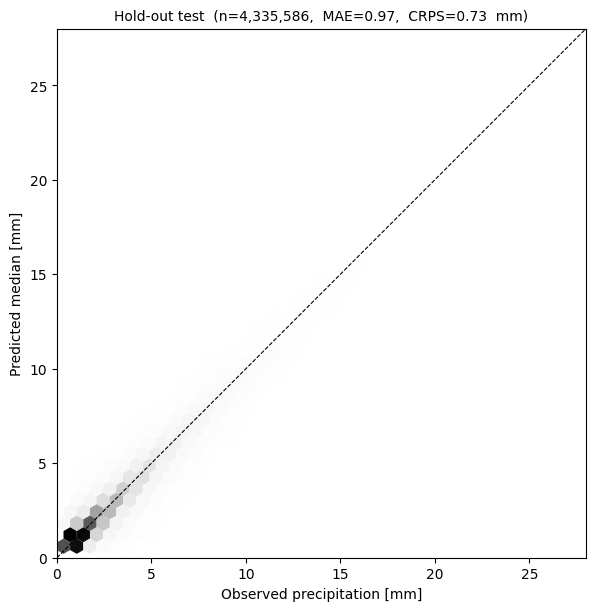

In [10]:
fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)

vmax = max(df_test['precip_mm'].quantile(0.99), df_test['q50'].quantile(0.99))
lim  = (0, float(np.ceil(vmax)))

ax.hexbin(df_test['precip_mm'], df_test['q50'],
          gridsize=40, extent=(*lim, *lim),
          cmap='Greys', mincnt=1, linewidths=0)
ax.plot(lim, lim, 'k--', lw=0.8)
ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect('equal')
ax.set_xlabel('Observed precipitation [mm]')
ax.set_ylabel('Predicted median [mm]')
ax.set_title(f'Hold-out test  (n={len(df_test):,},  '
             f'MAE={test_mae:.2f},  CRPS={test_crps:.2f}  mm)', fontsize=10)

plt.savefig(FIG_DIR / 'test_scatter_q50.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Quantile Calibration on Test

Fraction of test obs that fall below each predicted quantile. Perfect calibration ⇒
empirical = nominal (the diagonal).

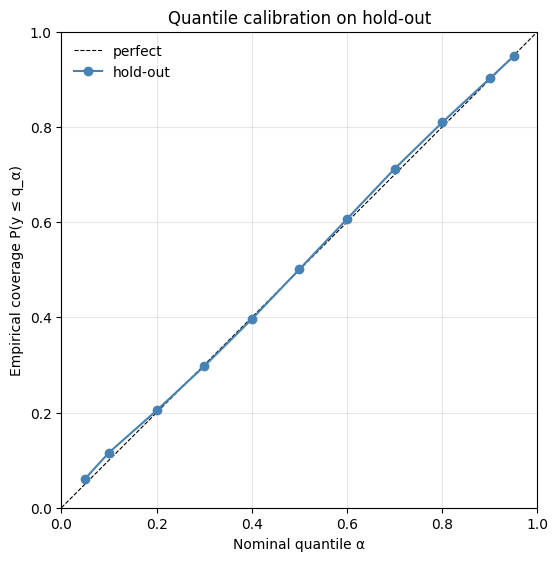

  α=0.05   empirical=0.061   gap=+0.011
  α=0.10   empirical=0.116   gap=+0.016
  α=0.20   empirical=0.204   gap=+0.004
  α=0.30   empirical=0.297   gap=-0.003
  α=0.40   empirical=0.396   gap=-0.004
  α=0.50   empirical=0.501   gap=+0.001
  α=0.60   empirical=0.607   gap=+0.007
  α=0.70   empirical=0.712   gap=+0.012
  α=0.80   empirical=0.809   gap=+0.009
  α=0.90   empirical=0.902   gap=+0.002
  α=0.95   empirical=0.948   gap=-0.002


In [11]:
y_true = df_test['precip_mm'].values
emp = []
for alpha in QUANTILES:
    pred = df_test[f'q{int(alpha * 100):02d}'].values
    emp.append(float((y_true <= pred).mean()))

fig, ax = plt.subplots(figsize=(5.5, 5.5), constrained_layout=True)
ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='perfect')
ax.plot(QUANTILES, emp, 'o-', color='steelblue', lw=1.5, label='hold-out')
ax.set_xlabel('Nominal quantile α')
ax.set_ylabel('Empirical coverage P(y ≤ q_α)')
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
ax.set_title('Quantile calibration on hold-out')
ax.legend(frameon=False)
ax.grid(True, alpha=0.3)
plt.savefig(FIG_DIR / 'test_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

for alpha, e in zip(QUANTILES, emp):
    print(f'  α={alpha:.2f}   empirical={e:.3f}   gap={e - alpha:+.3f}')

## 10. CRPS / MAE by Precipitation Intensity (Test)

             n     mae    crps    bias
bin                                   
0.5–2  1706499   0.441   0.331   0.238
2–5    1339286   0.770   0.582  -0.033
5–10    798928   1.270   0.970  -0.324
10–20   380013   2.184   1.673  -0.910
20–50   105669   4.565   3.532  -2.773
50+       5183  13.982  10.904 -11.218


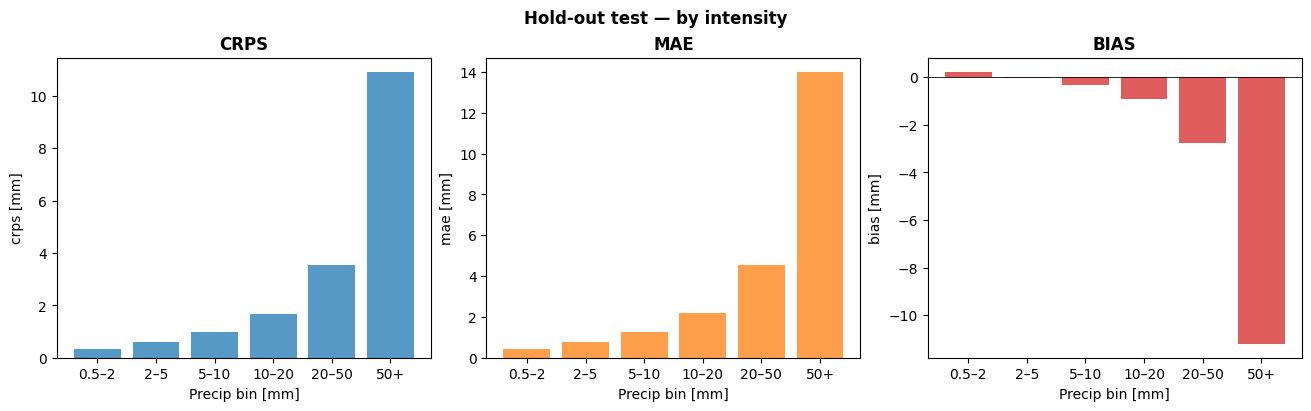

In [12]:
bins   = [0.5, 2, 5, 10, 20, 50, 200]
labels = ['0.5–2', '2–5', '5–10', '10–20', '20–50', '50+']
df_test['bin'] = pd.cut(df_test['precip_mm'], bins=bins, labels=labels, include_lowest=True)

agg = df_test.groupby('bin').agg(
    n    = ('precip_mm',     'size'),
    mae  = ('error',         lambda s: s.abs().mean()),
    crps = ('crps',          'mean'),
    bias = ('error',         'mean'),
)
print(agg.round(3))

fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
for ax, col, color in zip(axes, ['crps', 'mae', 'bias'],
                          ['tab:blue', 'tab:orange', 'tab:red']):
    ax.bar(agg.index.astype(str), agg[col], color=color, alpha=0.75)
    if col == 'bias':
        ax.axhline(0, color='k', lw=0.6)
    ax.set_title(col.upper(), fontweight='bold')
    ax.set_xlabel('Precip bin [mm]')
    ax.set_ylabel(f'{col} [mm]')
fig.suptitle('Hold-out test — by intensity', fontsize=12, fontweight='bold')
plt.savefig(FIG_DIR / 'test_by_intensity.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Spatial Test-Error Map

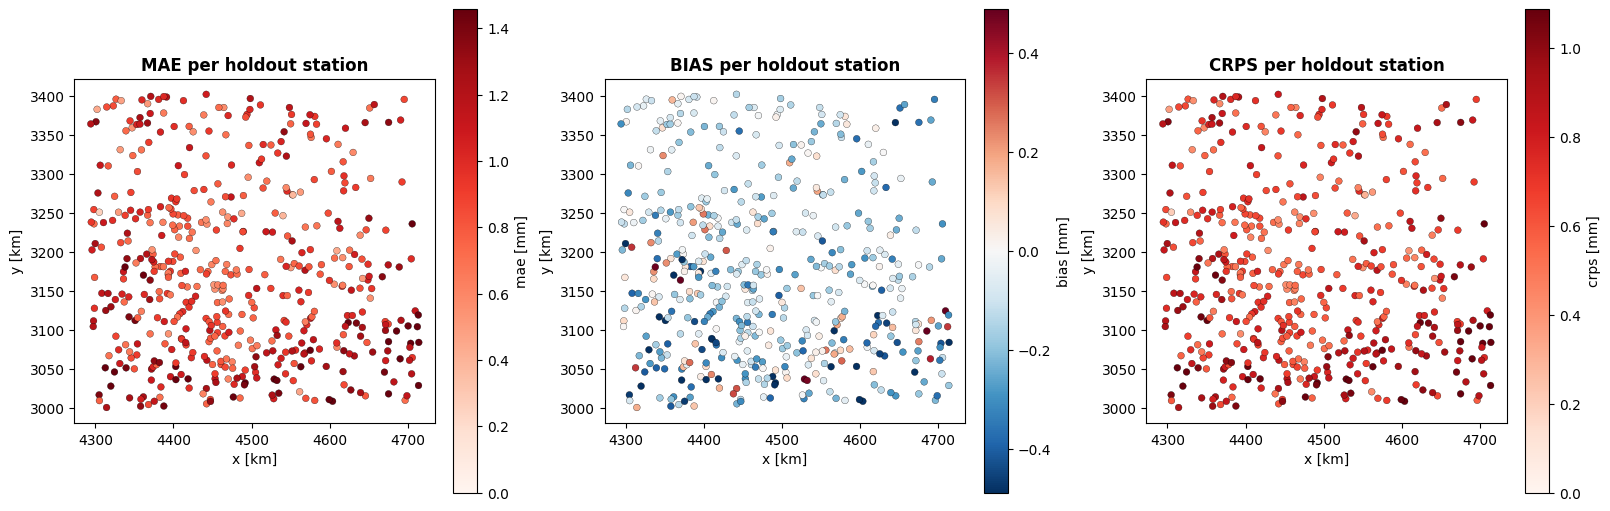

Worst 10 stations by MAE:
 station_id      mae      bias     crps     n       x_proj       y_proj
CZ_L3KLIN01 2.104861  0.466554 1.592959 10274 4.532297e+06 3.035573e+06
CZ_U2HEJN01 1.912856  0.497781 1.374742  9839 4.685410e+06 3.098818e+06
   DWD_2742 1.853434 -0.621701 1.445809 10473 4.319790e+06 3.028329e+06
CZ_P2ROKY01 1.841302 -0.418785 1.347363 10137 4.703475e+06 3.083094e+06
CZ_P2KOST01 1.754703 -0.184032 1.338918  7478 4.675175e+06 3.018436e+06
    DWD_501 1.733359 -0.409236 1.328057 10164 4.324475e+06 3.046461e+06
CZ_L3BDAR01 1.724930  0.606529 1.319485 11145 4.528819e+06 3.037303e+06
   DWD_2317 1.716013  0.098373 1.271839 10460 4.574964e+06 3.074171e+06
   DWD_3829 1.712279  0.476667 1.254984  9967 4.337994e+06 3.180766e+06
CZ_H3NBYD01 1.655577 -0.180434 1.240449  7531 4.713532e+06 3.029145e+06


In [13]:
station_err = (
    df_test.groupby('station_id')
           .agg(mae=('error', lambda s: s.abs().mean()),
                bias=('error', 'mean'),
                crps=('crps',  'mean'),
                n=('precip_mm', 'size'))
           .reset_index()
           .merge(station_meta[['station_id', 'x_proj', 'y_proj']], on='station_id', how='left')
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
for ax, col, cmap, vsym in zip(axes,
                                ['mae', 'bias', 'crps'],
                                ['Reds', 'RdBu_r', 'Reds'],
                                [False, True, False]):
    if vsym:
        v = float(np.nanpercentile(np.abs(station_err[col]), 95))
        kw = dict(vmin=-v, vmax=v)
    else:
        kw = dict(vmin=0, vmax=float(np.nanpercentile(station_err[col], 95)))
    sc = ax.scatter(station_err['x_proj'] / 1000, station_err['y_proj'] / 1000,
                    c=station_err[col], cmap=cmap, s=24, edgecolor='k', linewidth=0.2, **kw)
    plt.colorbar(sc, ax=ax, label=f'{col} [mm]')
    ax.set_title(f'{col.upper()} per holdout station', fontweight='bold')
    ax.set_xlabel('x [km]'); ax.set_ylabel('y [km]')
    ax.set_aspect('equal')
plt.savefig(FIG_DIR / 'test_spatial_error.png', dpi=150, bbox_inches='tight')
plt.show()

print('Worst 10 stations by MAE:')
print(station_err.sort_values('mae', ascending=False).head(10).to_string(index=False))

## 12. 90 % Prediction-Interval Coverage on Test

  90% PI coverage:  0.905   (target 0.90)
  90% PI width:     mean=4.340   median=3.122  mm


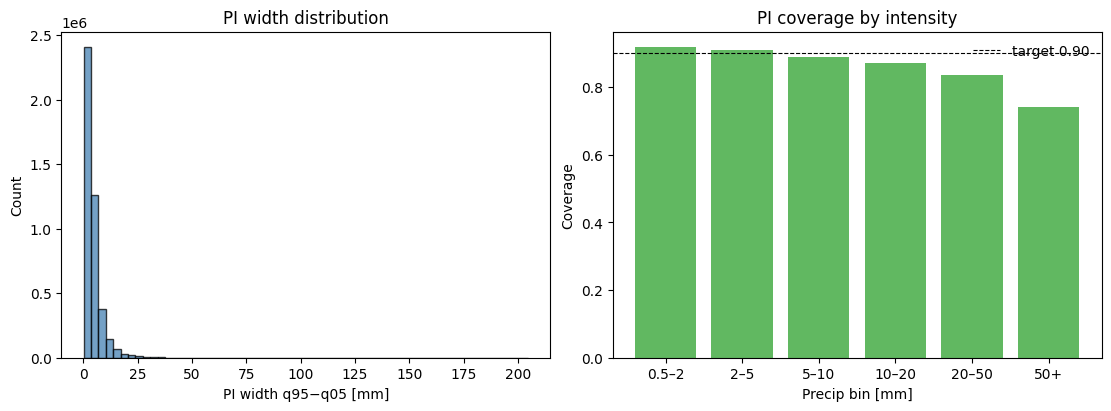

In [14]:
df_test['pi_width'] = df_test['q95'] - df_test['q05']
df_test['in_pi']    = (df_test['precip_mm'] >= df_test['q05']) & (df_test['precip_mm'] <= df_test['q95'])

print(f'  90% PI coverage:  {df_test["in_pi"].mean():.3f}   (target 0.90)')
print(f'  90% PI width:     mean={df_test["pi_width"].mean():.3f}   '
      f'median={df_test["pi_width"].median():.3f}  mm')

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].hist(df_test['pi_width'], bins=60, color='steelblue', edgecolor='k', alpha=0.75)
axes[0].set_xlabel('PI width q95−q05 [mm]')
axes[0].set_ylabel('Count')
axes[0].set_title('PI width distribution')

by_bin = df_test.groupby('bin').agg(
    coverage=('in_pi',    'mean'),
    width=   ('pi_width', 'mean'),
)
axes[1].bar(by_bin.index.astype(str), by_bin['coverage'], color='tab:green', alpha=0.75)
axes[1].axhline(0.90, color='k', ls='--', lw=0.8, label='target 0.90')
axes[1].set_xlabel('Precip bin [mm]')
axes[1].set_ylabel('Coverage')
axes[1].set_title('PI coverage by intensity')
axes[1].legend(frameon=False)
plt.savefig(FIG_DIR / 'test_pi_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Example Day — Actual | Predicted | Error

Pick one wet day with many holdout stations and visualise the spatial pattern of
observation, prediction and error.

Example date: 1970-07-19


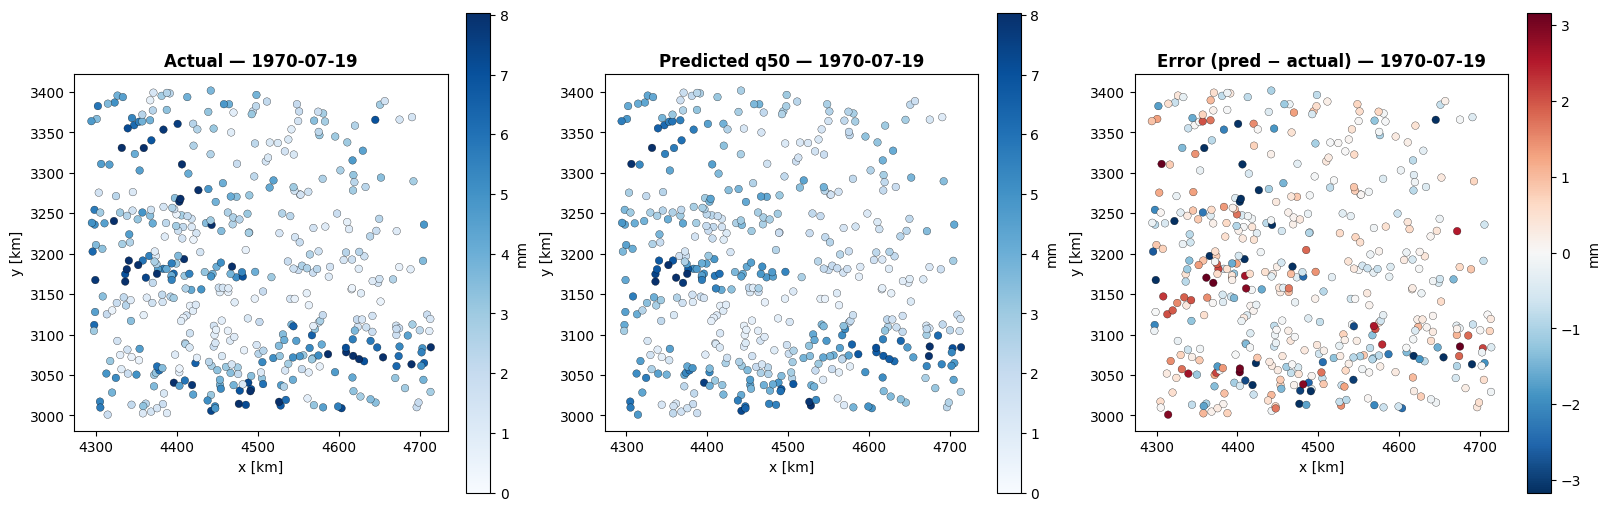


1970-07-19:  n=454  CRPS=0.713  MAE=0.944  bias=-0.137 mm


In [17]:
day_counts   = df_test.groupby('date')['station_id'].count()
example_date = day_counts[day_counts > 400].sample(1, random_state=42).index[0]
print(f'Example date: {example_date}')

df_day  = df_test[df_test['date'] == example_date].copy()
vmax    = float(df_day['precip_mm'].quantile(0.95))
vmaxerr = float(df_day['error'].abs().quantile(0.95))

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

sc0 = axes[0].scatter(df_day['x_proj'] / 1000, df_day['y_proj'] / 1000,
                      c=df_day['precip_mm'], cmap='Blues', s=30, vmin=0, vmax=vmax,
                      edgecolor='k', linewidth=0.2)
plt.colorbar(sc0, ax=axes[0], label='mm'); axes[0].set_title(f'Actual — {example_date}', fontweight='bold')

sc1 = axes[1].scatter(df_day['x_proj'] / 1000, df_day['y_proj'] / 1000,
                      c=df_day['q50'], cmap='Blues', s=30, vmin=0, vmax=vmax,
                      edgecolor='k', linewidth=0.2)
plt.colorbar(sc1, ax=axes[1], label='mm'); axes[1].set_title(f'Predicted q50 — {example_date}', fontweight='bold')

sc2 = axes[2].scatter(df_day['x_proj'] / 1000, df_day['y_proj'] / 1000,
                      c=df_day['error'], cmap='RdBu_r', s=30, vmin=-vmaxerr, vmax=vmaxerr,
                      edgecolor='k', linewidth=0.2)
plt.colorbar(sc2, ax=axes[2], label='mm'); axes[2].set_title(f'Error (pred − actual) — {example_date}', fontweight='bold')

for ax in axes:
    ax.set_xlabel('x [km]'); ax.set_ylabel('y [km]'); ax.set_aspect('equal')

plt.savefig(FIG_DIR / f'test_example_day_{example_date}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n{example_date}:  n={len(df_day)}  '
      f'CRPS={df_day["crps"].mean():.3f}  '
      f'MAE={df_day["error"].abs().mean():.3f}  '
      f'bias={df_day["error"].mean():+.3f} mm')